# **AI 500 - PA4** 

## Overview
This assignment covers Causal Inference and Exploratory Data Analysis (EDA). Complete all questions and follow the submission rules below.


## Instructions
- Attempt **all questions**.  
- Run **every notebook cell** sequentially. For the coding questions, each cell must display its result (print values, show tables or visualizations).  
- For the analytical questions, write your answers in the markdown cell provided to you below each question.
- All necessary imports are already provided — do not make any more imports.
- Fill the top markdown cell with your **Full Name** and **Roll Number**.  
- Save your notebook exactly as `PA4_<your_roll_number>.ipynb` (example: `PA4_26100053.ipynb`).  
- Due date: **22 November 2025** (submit by 23:55).  
- Plagiarism is <span style="color:red">strictly prohibited — submit your own original work.</span>

Write your name and roll number here:
- `Name: Rana Taqveem Ul Hassan`
- `Roll number: 25280030`

**Credit:** Based on the assignment developed during Dr. Ihsan Ayub Qazi's CS 334, Fall 2024 offering.


---

## **Part A - Analyzing the Impact of Castle Doctrine Laws on Violent Crime Rates**

### Introduction

The **Castle Doctrine** is a legal principle that grants individuals the right to use reasonable force, including deadly force, to defend themselves against an intruder within their own homes. Rooted in the notion that one's home is their "castle," these laws eliminate the duty to retreat before using force in self-defense. Proponents argue that the Castle Doctrine empowers lawful homeowners to protect themselves and deters criminal activity, while critics express concerns that such laws may escalate violence and lead to an increase in homicides.

Understanding the **causal relationship** between the implementation of Castle Doctrine laws and changes in violent crime rates is crucial for policymakers, law enforcement agencies, and communities. By analyzing this relationship, we can assess whether these laws effectively reduce crime or inadvertently contribute to higher rates of violence.

### Dataset Overview

This analysis utilizes a comprehensive dataset from the **FBI**, encompassing various states over multiple years. The dataset captures a wide range of variables related to violent crimes, socioeconomic conditions, and demographic factors. Notably, the implementation of Castle Doctrine laws occurred at different times across states, with the majority adopting these statutes around **2006**. This staggered adoption provides a unique opportunity to employ robust methodologies to isolate the effect of these laws on violent crime rates.

### Selected Columns for Analysis

For a focused and meaningful analysis, we restrict our examination to the following columns from the dataset:

| **Column**         | **Description**                                                                                                                                                                                                                 |
|--------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `year`             | The calendar year of the observation (e.g., 2005, 2010).                                                                                                                                                                       |
| `post`             | A binary indicator where `1` signifies the post-treatment period (after the implementation of Castle Doctrine laws) and `0` denotes the pre-treatment period.                                                                    |
| `sid`              | The state identifier, uniquely representing each state in the dataset.                                                                                                                                                       |
| `homicide`         | The number of homicides recorded in the state per 100,000 population for the given year.                                                                                                                                       |
| `robbery`          | The number of robberies reported in the state per 100,000 population for the given year.                                                                                                                                        |
| `larceny`          | The number of larcenies recorded in the state per 100,000 population for the given year.                                                                                                                                        |
| `assault`          | The number of aggravated assaults reported in the state per 100,000 population for the given year.                                                                                                                              |
| `burglary`         | The number of burglaries recorded in the state per 100,000 population for the given year. 
| `l_exp_pubwelfare`         | Logged public welfare spending                                                                                                                                        |
| `l_police`         | Logged police presence                                                                                                                                        |
| `l_income`         | Logged income                                                                                                                                        |
| `murder`           | The number of murders reported in the state per 100,000 population for the given year.                                                                                                                                          |
| `unemployrt`       | The unemployment rate in the state for the given year, serving as an economic indicator.                                                                                                                                          |
| `poverty`          | The poverty rate in the state for the given year, reflecting socioeconomic conditions.                                                                                                                                           |
| `blackm_15_24`     | The percentage of Black males aged 15-24 in the state for the given year.                                                                                                                                                        |
| `whitem_15_24`     | The percentage of White males aged 15-24 in the state for the given year.                                                                                                                                                        |
| `popwt`     | Population weight                                                                                                                                                                                                                       |

### **Crime Definitions**

To ensure clarity in our analysis, it's essential to define each of the key crime-related variables included in our dataset:

| **Variable**   | **Definition**                                                                                                                                                                                                                     |
|----------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Homicide**   | **Homicide** is defined as the sum of **murder** and **non-negligent manslaughter**. It represents the total number of intentional killings within a state, normalized per 100,000 state population.                                 |
| **Murder**     | **Murder** refers to the unlawful killing of another human being without justification or valid excuse, committed with the necessary intention as defined by the law in a specific jurisdiction.                                           |
| **Larceny**    | **Larceny** is the unlawful taking and carrying away of personal property with the intent to deprive the rightful owner of it permanently. It encompasses various forms of theft that do not involve force or intimidation.               |
| **Assault**    | **Assault** involves the act of causing physical harm or unwanted physical contact to another person. This includes aggravated assaults, which are more severe and may involve the use of weapons or intent to cause serious injury.       |
| **Burglary**   | **Burglary** is the act of illegally entering a building or other areas without permission, typically with the intention of committing a further criminal offense inside. It does not necessarily involve theft or violence.            |
| **Robbery**    | **Robbery** is the act of taking property or money from a person through force, intimidation, or threat of violence. Unlike larceny, robbery involves direct confrontation and coercion against the victim.                                |


### **Temporal and Spatial Dimensions**

The dataset spans multiple states across the United States and covers several years, allowing for a longitudinal analysis of crime trends in relation to the implementation of Castle Doctrine laws. Most states adopted these statutes around **2006**, but the exact year of implementation varies, providing a natural experiment setting to evaluate the laws' impact. By comparing states before and after the adoption period and against states that did not adopt the law during the study period, we can effectively employ different techniques to infer causality.

---



In [220]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dowhy
from sklearn.linear_model import LinearRegression

Q1) Load `castle_doctrine_1.csv` into `df_1` and `castle_doctrine_2.csv` into `df_2`. Display the first 5 rows of `df_1` and last 5 rows of `df_2`.

In [221]:
df_1 = pd.read_csv('castle_doctrine_1.csv')
df_2 = pd.read_csv('castle_doctrine_2.csv')

# print(len(df_1))
# print(len(df_2))
print(df_1.iloc[:5, :])
print(df_2.iloc[:5, :])

    id    year   sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0  575     NaN   6.0   0.0          6.774674  5.495338  10.821630    4.138185   
1  277  2002.0  27.0   0.0          6.807210  5.723646  10.650625    4.500000   
2  104  2005.0  11.0   0.0          7.077266  5.788776  10.845290    5.100000   
3  177  2001.0  18.0   0.0          7.218498  5.530656  10.765047    5.200000   
4  456  2005.0  43.0   0.0          7.487087  6.031345  10.692172    5.500000   

     poverty  blackm_15_24  whitem_15_24       popwt  
0  11.203561           NaN           NaN         NaN  
1  14.261345      0.754476     12.723339   921333.75  
2  14.413202      0.048599      0.298499  8871351.00  
3  14.815132      3.269265      5.064819  4105912.00  
4  15.560262      3.887660     13.213633  5885931.50  
   id  homicide    murder    robbery    assault    burglary    larceny
0   0  7.593978  6.532207  131.61357  325.61780   930.92017  2940.6238
1   1  8.713443  7.494940  128.37960  281

Q2.1) Store the total number of null values in both datasets in `nullTotal`.

In [222]:
df_1_col_wise_nulls = df_1.isnull().sum()
df_1_total_nulls =  df_1_col_wise_nulls.sum()
# print(f"df_1_total_nulls: {df_1_total_nulls}")

df_2_col_wise_nulls = df_2.isnull().sum()
df_2_total_nulls =  df_2_col_wise_nulls.sum()
# print(f"df_2_total_nulls: {df_2_total_nulls}")

nullTotal = df_1_total_nulls + df_2_total_nulls
print(f"Total Nulls: {nullTotal}")

df_1_col_wise_notnulls = df_1.notnull().sum()
df_1_total_notnulls =  df_1_col_wise_notnulls.sum()
# print(f"df_1_total_notnulls: {df_1_total_notnulls}")

df_2_col_wise_notnulls = df_2.notnull().sum()
df_2_total_notnulls =  df_2_col_wise_notnulls.sum()
# print(f"df_2_total_notnulls: {df_2_total_notnulls}")

notnullsTotal = df_1_total_notnulls + df_2_total_notnulls
# print(f"Total Nulls: {notnullsTotal}")


Total Nulls: 157


Q2.2) Store the number of rows containing null values in both datasets in `rowsNull`.

In [223]:
# df_1_rows = df_1.isnull()
# print(len(df_1_rows))
# print(df_1_rows)
# print(df_1_rows.any(axis=1).sum())

df_1_row_wise_nulls = df_1.isnull().any(axis=1).sum()
df_2_row_wise_nulls = df_2.isnull().any(axis=1).sum()

# print(f"df_1_row_wise_nulls: {df_1_row_wise_nulls}")
# print(f"df_2_row_wise_nulls: {df_2_row_wise_nulls}")
rowsNulls = df_1_row_wise_nulls + df_2_row_wise_nulls

print(f"rowNulls: {rowsNulls}")

rowNulls: 30


Q3) Drop all rows containing null values, and print the sizes of the resulting datasets.

In [225]:
print(f"df_1 size: {len(df_1)}")
print(f"df_2 size: {len(df_2)}")

df_1 = df_1.dropna()
df_2 = df_2.dropna()

print(f"df_1 size: {len(df_1)}")
print(f"df_2 size: {len(df_2)}")

df_1 size: 550
df_2 size: 550
df_1 size: 550
df_2 size: 550


Q4) Note that the id column in `df_1` is shuffled and not in order. Sort all the rows in the dataframe in ascending order using the `id` column.

In [226]:
df_1 = df_1.sort_values(by="id", ascending=True)
df_2 = df_2.sort_values(by="id", ascending=True)

Q5.1) The dataset is split across two files; both files share an `id` column with identical row counts and therefore, a one-to-one mapping — join them on `id` and store the merged table in a variable named `df`.

In [227]:
df = df_1.merge(df_2, how='inner', on='id')
print(df.iloc[:2, :])

# df.to_csv('complete_data.csv', index = False)


   id    year  sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0   0  2000.0  1.0   0.0          6.926083  5.854609  10.711102         4.1   
1   1  2001.0  1.0   0.0          6.974412  5.863135  10.675931         4.7   

     poverty  blackm_15_24  whitem_15_24      popwt  homicide    murder  \
0  14.705981      2.222243      4.694810  4499293.0  7.593978  6.532207   
1  15.750203      2.249954      4.700201  4499293.0  8.713443  7.494940   

     robbery    assault   burglary    larceny  
0  131.61357  325.61780  930.92017  2940.6238  
1  128.37960  281.63504  934.38460  2758.6900  


Q5.2) We do not need the `id` column any longer. Drop the `id` column.

In [229]:
df = df.drop(['id'], axis=1, errors='ignore')
print(df.iloc[:2, :])

     year  sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0  2000.0  1.0   0.0          6.926083  5.854609  10.711102         4.1   
1  2001.0  1.0   0.0          6.974412  5.863135  10.675931         4.7   

     poverty  blackm_15_24  whitem_15_24      popwt  homicide    murder  \
0  14.705981      2.222243      4.694810  4499293.0  7.593978  6.532207   
1  15.750203      2.249954      4.700201  4499293.0  8.713443  7.494940   

     robbery    assault   burglary    larceny  
0  131.61357  325.61780  930.92017  2940.6238  
1  128.37960  281.63504  934.38460  2758.6900  


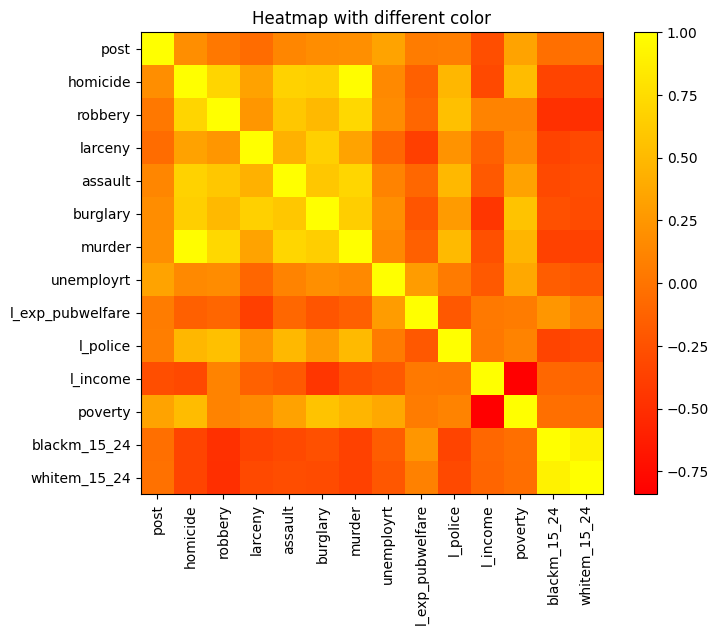

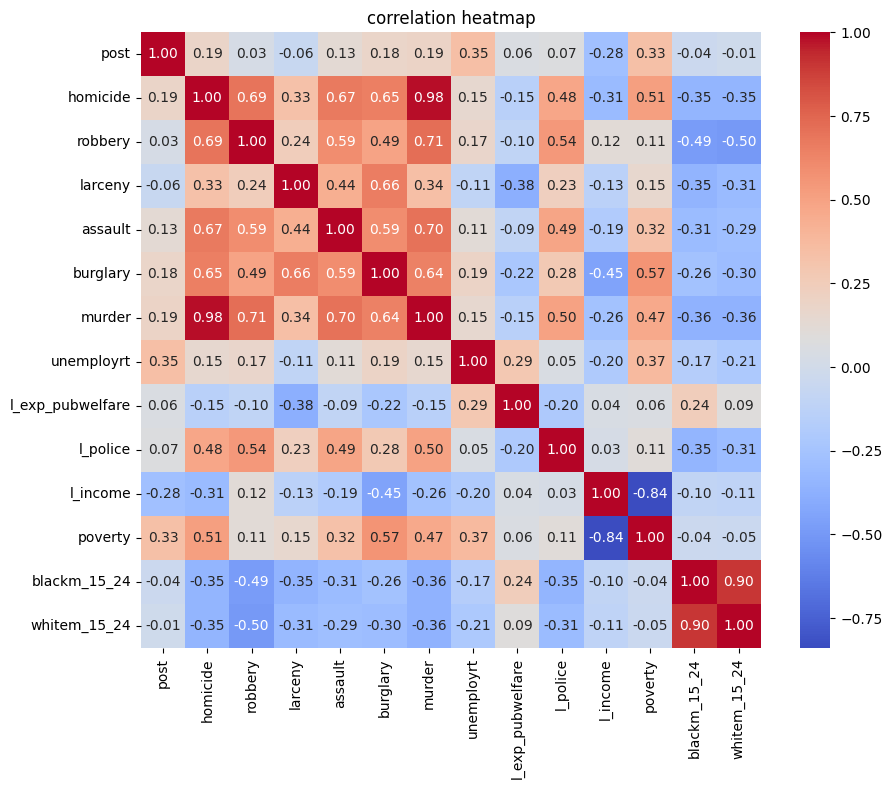

In [230]:
selected_columns = ['post', 'homicide', 'robbery', 'larceny', 
                    'assault', 'burglary', 'murder', 'unemployrt','l_exp_pubwelfare' ,'l_police','l_income',
                    'poverty', 'blackm_15_24', 'whitem_15_24']


corr_df = df[selected_columns]

correlation_matrix = corr_df.corr()
columns = correlation_matrix.columns
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap='autumn', interpolation='nearest')

# Add colorbar
plt.colorbar()

plt.xticks(range(len(columns)), columns, rotation=90)
plt.yticks(range(len(columns)), columns)
plt.title("Heatmap with different color")
plt.show()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()
#  df.groupby('Class')['V5'].describe()
# df.groupby('Class')['Amount'].describe()

abs_correlation = correlation_matrix.abs()

top3_per_col = {}
police_rel = {}
poverty_rel = {}
unemploymentrt = {}
for col in abs_correlation.columns:
    if col == 'l_police':
        police_rel[col] = correlation_matrix[col].sort_values(ascending=False)
        
    if col == 'poverty':
        poverty_rel[col] = correlation_matrix[col].sort_values(ascending=False)
        
    if col == 'unemployrt':
        unemploymentrt[col] = correlation_matrix[col].sort_values(ascending=False)
    
    t3 = abs_correlation[col].drop(labels=[col]).sort_values(ascending=False).head(3)
    top3_per_col[col] = t3

# for col, vals in top3_per_col.items():
#     print(f"\n Top 3 correlated columns with '{col}:")
#     print(vals)

# print(police_rel)
# print(poverty_rel)
# print(unemploymentrt)


Q6.2) Comment on any 3 notable correlations. Based on these correlations, can you say that any of the correlations you suggested are causally related? If so, is their causal relationship direct or indirect, and are there any cofounding variables you suspect? Otherwise, explain why you weren't able to deduce any causal relaion.

Note: You will be graded on how critically you have commented, not how much you write. So keep your answers crisp and to the point, but also think deeply. 

<span style="color:lightgreen"> Answer: </span>


We can see multiple notable correlations like:

1. The crime categories (Homicide, Murder, Robbery, Assult, Burglary) shows string positive correlated. This is expected as  they increase and decrease together, but they donot casue each other but they share underlying social and economic factors.

2. Police presence also shows a strong positive correlation with violent crimes like homicide, murders, robbary, assult. However, this does not mean policy causes crime, rahther its other way around, when crime increase, governments deploy more police. Therefor, Crime directly causes increase police presence.

3. Poverty shows a consistant positive correlation with several crimes, such as burglary, assult, murder. Thus poverty result in increase in crime a direct effect and crime increases police deployment (indirect effect)

DAG

Poverty  -----> Crime Categories( murder, homicide, assualt, burglary) -------> Police Presence  



Q7.1) Estimate the average treatment effect on Homicide before and after the doctrine was implemented using the post attribute in your dataset, without conditioning on any variable. Store your answer in the `ATE` variable.

In [231]:

homicide_data = df.groupby('post')['homicide'].mean()
print(homicide_data)
ATE = homicide_data.loc[1] - homicide_data.loc[0]
print(f'Homicide ATE: {ATE}')

post
0.0    4.579918
1.0    5.928761
Name: homicide, dtype: float64
Homicide ATE: 1.3488435295735854


Q7.2) What might the issue with the calculated ATE?

<span style="color:lightgreen"> Answer: </span>

A positive simple before and after difference in means (ATE) indicates that homicide levels increased after the docitrine was implemented. However, this comparision is most likely misleading. This apparent increase in numbers of homicides could be driven by several underlying trends and causes over time, like existing factors like poverty levels, policing deployment and effectiveness, demographics, and socio-economics.  Therefore, without accounting for these varaibles the raw observed ATE is not a causal estimate, its just a naive comparision.

Q8) Create a plot that shows the number of observations in the pre-treatment and post-treatment periods. Make sure your graph is properly labelled.

C:\Users\rana.taqveem\AppData\Local\Temp\ipykernel_13424\1566110265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.countplot(x='post', data=df, palette=palette, edgecolor='grey')
C:\Users\rana.taqveem\AppData\Local\Temp\ipykernel_13424\1566110265.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(['Pre-treatment', 'Post-treatment'])


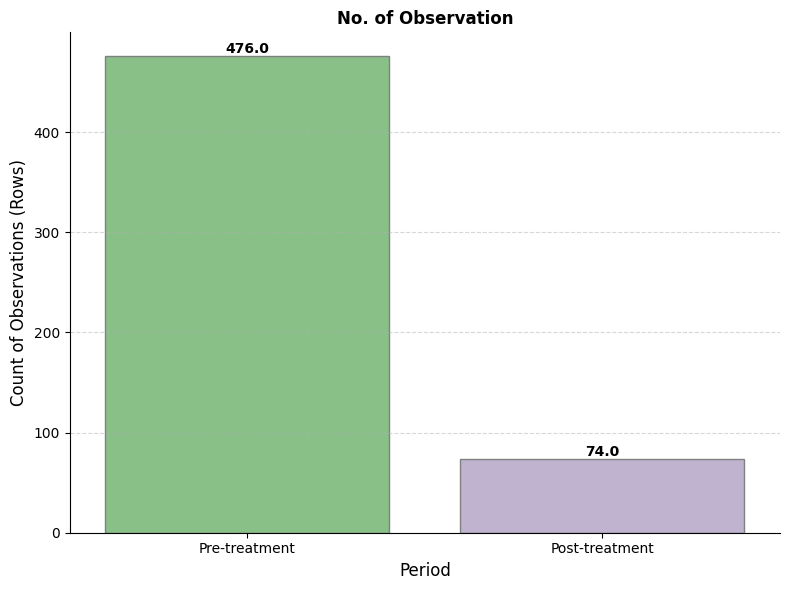

In [232]:

plt.figure(figsize=(8, 6))

palette = sns.color_palette("Accent", n_colors=2)
axes = sns.countplot(x='post', data=df, palette=palette, edgecolor='grey')
axes.set_title('No. of Observation', fontsize=12, weight='bold')
axes.set_ylabel('Count of Observations (Rows)', fontsize=12)
axes.set_xlabel('Period', fontsize=12)
axes.set_xticklabels(['Pre-treatment', 'Post-treatment'])

for p in axes.patches:
    h = p.get_height()
    axes.annotate(f'{h}',
                  (p.get_x() + p.get_width()/2., h),
                  ha='center', va='bottom', 
                  fontsize=10, weight='bold')
    
sns.despine()
axes.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


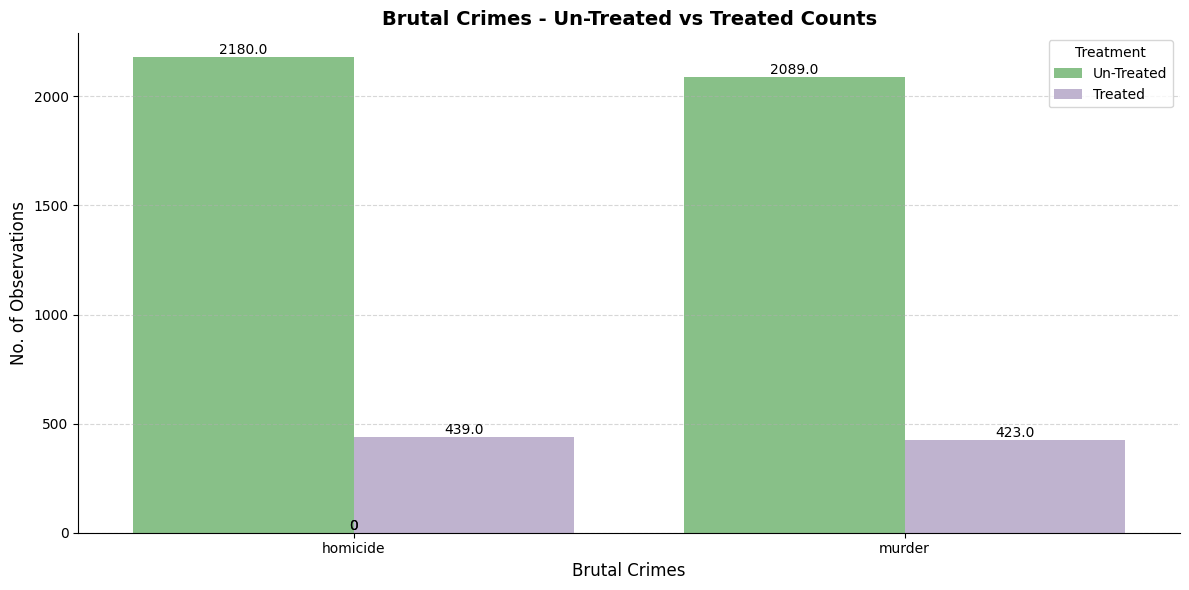

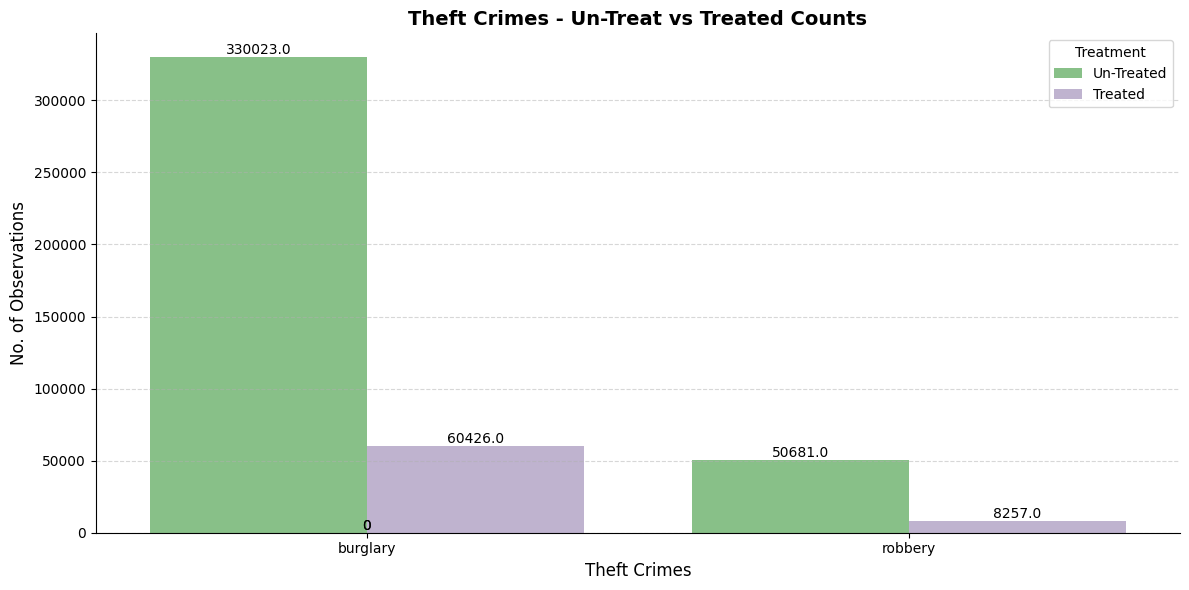

In [233]:

def ccw_treated_vs_untreaded(dataf, crime_to_observe, plot_title, x_label, y_label ):
    
    untreated_df = dataf.loc[df['post'] == 0.0]
    untreated_sum = round(untreated_df[crime_to_observe].sum()).reset_index(name='Un-Treated')
    # print(f'untreated_sums: {untreated_sum}')

    treated_df = dataf.loc[df['post'] == 1.0]
    treated_sum = round(treated_df[crime_to_observe].sum()).reset_index(name='Treated')

    # print(treated_sum)
    merged = untreated_sum.merge(treated_sum, on='index', how='outer').fillna(0)

    # print(merged)
    df_melted = merged.melt(id_vars='index',
                          value_vars=['Un-Treated', 'Treated'],
                          var_name='Treatment',
                          value_name='Count')


    plt.figure(figsize=(12, 6))
    palette = sns.color_palette("Accent", n_colors=2)
    axes = sns.barplot(x='index', y='Count', hue='Treatment', data=df_melted, palette=palette)
    axes.set_title(plot_title, fontsize=14, weight='bold')
    axes.set_ylabel(y_label, fontsize=12)
    axes.set_xlabel(x_label, fontsize=12)

    for p in axes.patches:
        h = p.get_height()
        axes.annotate(f'{h}',
                  (p.get_x() + p.get_width()/2., h),
                  ha='center', va='bottom', 
                  fontsize=10)
    
    sns.despine()
    axes.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


###############################################################################################

crime_to_observe = ['homicide', 'murder']
plot_title ='Brutal Crimes - Un-Treated vs Treated Counts'
x_label = 'Brutal Crimes'
y_label = 'No. of Observations'

ccw_treated_vs_untreaded(df, crime_to_observe, plot_title, x_label, y_label )

###############################################################################################

# print(post)
crime_to_observe = ['robbery', 'burglary']
plot_title ='Theft Crimes - Un-Treat vs Treated Counts'
x_label = 'Theft Crimes'
y_label = 'No. of Observations'

ccw_treated_vs_untreaded(df, crime_to_observe, plot_title, x_label, y_label )


Q9.1) For the states that implemented the doctrine, use an appropriate plot to visualise the number of observations for the 5 states with the highest number of overall samples (pre and post). In the plot, separate counts for pre and post-treatment periods.

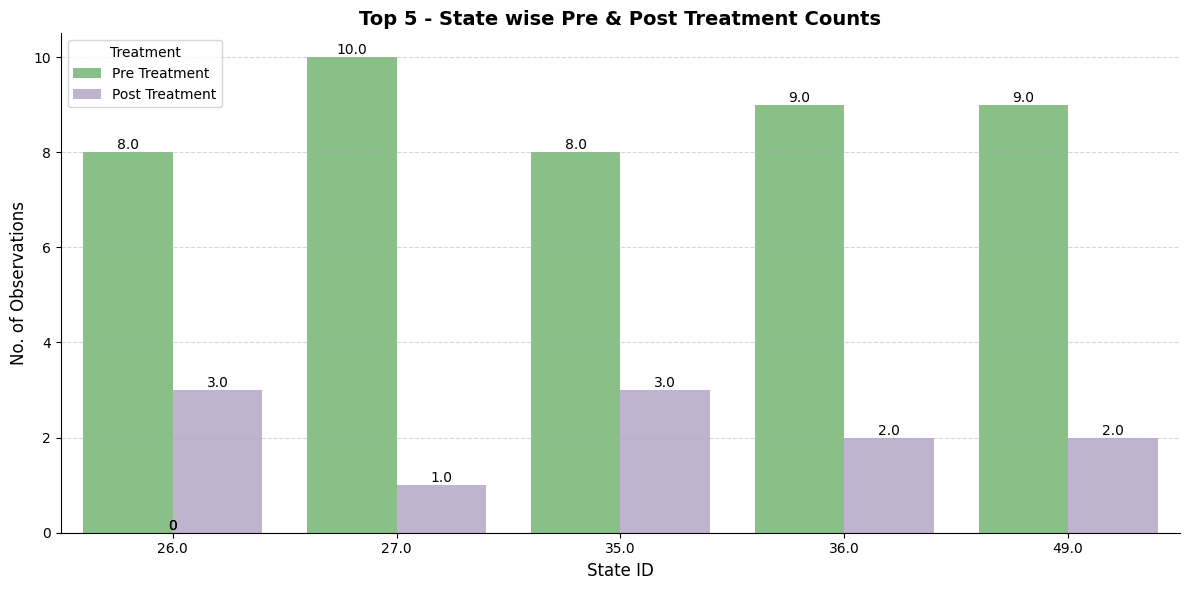

In [234]:
# print(df.count())

treated_sids = df[df['post'] == 1.0]['sid'].unique()

# print(treated_sids)
pre_treated = df[(df['post'] == 0.0) & (df['sid'].isin(treated_sids))]
pre_treated_counts = pre_treated.groupby('sid').size().reset_index(name='Pre Treatment')
post_treated_counts = df[df['post'] == 1.0].groupby('sid').size().reset_index(name='Post Treatment')

# print(f"Pre Treated: {pre_treated_counts}")
# print(f"Post Treated: {post_treated_counts}")

count_df = pre_treated_counts.merge(post_treated_counts, on='sid', how='inner').fillna(0)

count_df['total'] = count_df['Pre Treatment'] + count_df['Post Treatment']
# print(count_df)

top_five = count_df.sort_values(['Pre Treatment'], ascending=False).head(5)

df_melted = top_five.melt(id_vars='sid',
                          value_vars=['Pre Treatment', 'Post Treatment'],
                          var_name='Treatment',
                          value_name='Count')


plt.figure(figsize=(12, 6))
palette = sns.color_palette("Accent", n_colors=2)
axes = sns.barplot(x='sid', y='Count', hue='Treatment', data=df_melted, palette=palette)
axes.set_title('Top 5 - State wise Pre & Post Treatment Counts', fontsize=14, weight='bold')
axes.set_ylabel('No. of Observations', fontsize=12)
axes.set_xlabel('State ID', fontsize=12)

for p in axes.patches:
    h = p.get_height()
    axes.annotate(f'{h}',
                  (p.get_x() + p.get_width()/2., h),
                  ha='center', va='bottom', 
                  fontsize=10)
    
sns.despine()
axes.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


######################################################################################3



Q9.2) Since our dataset comprises of data from many states, we want to calculate the per state ATE. Before we do that, we are interested in the ATE of the states with more data samples. Therefore, calculate the per state ATE of the 5 states you've visualised above and display the results in a dataframe.

In [235]:
def compute_state_wise_ate_for_crime(states, crime_category):
    state_wise_df = df.groupby(['sid', 'post'])[crime_category].mean().reset_index(name='homicide mean')
    top_treated_only = state_wise_df[state_wise_df['sid'].isin(states)]
    sw_df_pivot = top_treated_only.pivot(index='sid', columns='post', values='homicide mean')
    sw_df_pivot.columns = ['control_mean', 'treated_mean']
    sw_df_pivot['ATE'] = sw_df_pivot['treated_mean'] - sw_df_pivot['control_mean']

    # print(sw_df_pivot)
    
    return sw_df_pivot

print(compute_state_wise_ate_for_crime(top_five['sid'], 'homicide'))

print('------------------------------------------------------------------------------------------------')

print(compute_state_wise_ate_for_crime(treated_sids, 'homicide'))




      control_mean  treated_mean       ATE
sid                                       
26.0      6.315173      7.121179  0.806006
27.0      2.944258      2.642913 -0.301345
35.0      1.352911      1.386991  0.034080
36.0      4.583821      4.353694 -0.230128
49.0      3.620422      3.996722  0.376300
------------------------------------------------------------------------------------------------
      control_mean  treated_mean       ATE
sid                                       
1.0       7.461809      7.239657 -0.222152
2.0       5.490787      4.528263 -0.962524
3.0       7.665295      7.133347 -0.531949
10.0      5.506912      6.041792  0.534881
11.0      7.240239      6.608315 -0.631924
15.0      5.911693      5.035126 -0.876567
17.0      4.383397      4.012131 -0.371267
18.0      4.794723      4.652908 -0.141815
19.0     12.569534     12.583059  0.013525
23.0      6.716056      6.002740 -0.713317
25.0      8.888911      7.176285 -1.712626
26.0      6.315173      7.121179  0.806006


Q9.3) Compute the overall CATE as follows:
- Select states that were treated in 2010.
- For each selected state, compute the state-level ATE on homicide:

Using the state-level ATEs, compute the CATE and report it.

In [ ]:
sids_treated_in_2010 = df[(df['post'] == 1.0) & (df['year'] == 2010)]['sid'].unique()

ate_for_2010_states = compute_state_wise_ate_for_crime(sids_treated_in_2010, 'homicide')

cate = ate_for_2010_states['ATE'].mean()
print(ate_for_2010_states)

print(f"CATE = {cate}")




      control_mean  treated_mean       ATE
sid                                       
1.0       7.461809      7.239657 -0.222152
2.0       5.490787      4.528263 -0.962524
3.0       7.665295      7.133347 -0.531949
10.0      5.506912      6.041792  0.534881
11.0      7.240239      6.608315 -0.631924
15.0      5.911693      5.035126 -0.876567
17.0      4.383397      4.012131 -0.371267
18.0      4.794723      4.652908 -0.141815
19.0     12.569534     12.583059  0.013525
23.0      6.716056      6.002740 -0.713317
25.0      8.888911      7.176285 -1.712626
26.0      6.315173      7.121179  0.806006
27.0      2.944258      2.642913 -0.301345
35.0      1.352911      1.386991  0.034080
36.0      4.583821      4.353694 -0.230128
37.0      5.510655      5.960620  0.449966
41.0      7.720881      7.097260 -0.623622
42.0      1.886030      3.799240  1.913210
43.0      7.076934      6.655962 -0.420971
44.0      6.220406      5.455810 -0.764596
49.0      3.620422      3.996722  0.376300
CATE = -0.2

Q9.4) Do you observe any evidence for the Simpson's Paradox for any individual state? If so, why do you think this might be the case?

<span style="color:lightgreen"> Answer: </span>

If we observe state-level ATE, most of the states have negative ATE or close to zero, same as the overall CATE (-0.208). However, for state no. 42 and state no. 26, their ATE is a large positive (1.913210), depicting a reversal in trend. This is a classic Simpson's Paradox. 

If we carefully look at the graph below and compare the number of homicide events in state 42, 26, vs the rest. It shows that where the reset of the states observed positive effect of treatment, and the number of homicides was reduced a bit. State 42 and state 26 show an inverted trend, and the number of homicides and murders increased substantially in these 2 states after the doctrine




C:\Users\rana.taqveem\AppData\Local\Temp\ipykernel_13424\3575261308.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(x='group', y='ATE', data=agg_df, palette=colors)


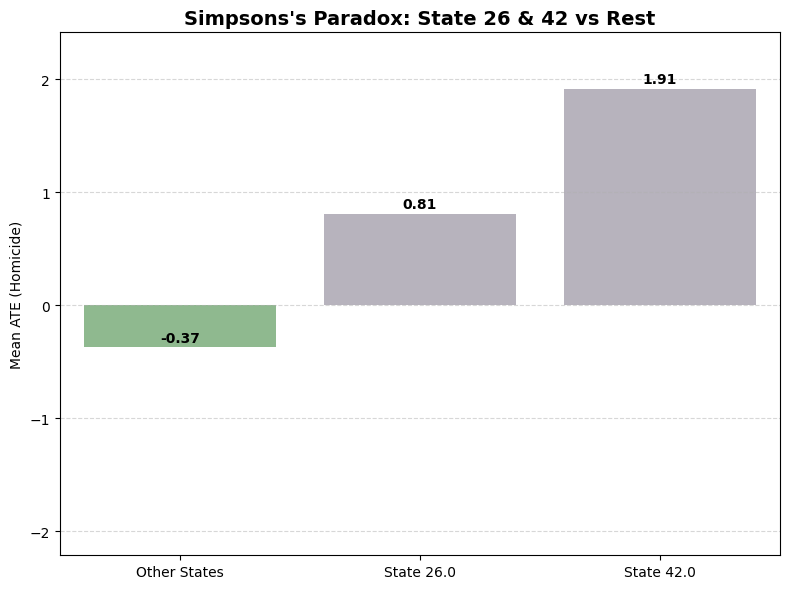

In [297]:
df_ate = pd.DataFrame(ate_for_2010_states).reset_index()

# print(df_ate)

df_ate['group'] = df_ate['sid'].apply(lambda x: f"State {x}" if x in [26, 42] else 'Other States')

agg_df = df_ate.groupby('group')['ATE'].mean().reset_index()


# print(agg_df)
plt.figure(figsize=(8,6))

colors = ['#B7B1BF' if g in ['State 26.0', 'State 42.0'] else '#88C088' for g in agg_df['group']]

axes = sns.barplot(x='group', y='ATE', data=agg_df, palette=colors)

axes.set_title("Simpsons's Paradox: State 26 & 42 vs Rest", fontsize=14, weight='bold')
axes.set_ylabel("Mean ATE (Homicide)")
axes.set_xlabel("")
axes.set_ylim(min(df_ate['ATE'])-0.5, max(df_ate['ATE'])+0.5)

for id, row in agg_df.iterrows():
    axes.text(id, row['ATE'] + 0.05, f"{row['ATE']:.2f}", ha='center', fontsize=10, weight='bold')
   
axes.grid(axis='y', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()


Q10) Now, report the ATE on Homicide using the DiD (Difference in Difference) formula where:

-   Assume the pre-intervention period is 2005, while the post-intervention period is 2010,
-   Given S defines your set of all states, your treatment group T consists of the states that have implemented the doctrine in 2010, and your control group are the states S\T in 2005 (i.e. the states apart from those incorporated in T)


In [271]:

sids_in_2010 = set(df[df['year'] == 2010]['sid'])
sids_in_2005 = set(df[df['year'] == 2005]['sid'])

common_sids = sids_in_2005 & sids_in_2010
df_in_test = df[df['sid'].isin(common_sids)]

# print(df_in_test)

treaded_sids = df_in_test[(df_in_test['post'] == 1.0) & (df_in_test['year'] == 2010)]['sid'].unique()

treated_homicide_in_2010 = df_in_test[(df_in_test['year'] == 2010) & (df_in_test['sid'].isin(treaded_sids))]['homicide'].mean()
treated_homicide_in_2005 = df_in_test[(df_in_test['year'] == 2005) & (df_in_test['sid'].isin(treaded_sids))]['homicide'].mean()

# # print (treated_df_in_2010['sid'].unique())
# # print (treated_df_in_2005['sid'].unique())

control_sids = common_sids - set(treaded_sids)
control_homicide_in_2005 = df_in_test[(df_in_test['year'] == 2005) & (df_in_test['sid'].isin(control_sids))]['homicide'].mean()
control_homicide_in_2010 = df_in_test[(df_in_test['year'] == 2010) & (df_in_test['sid'].isin(control_sids))]['homicide'].mean()


# print (control_df_in_2005['sid'].unique())
# print (control_df_in_2010['sid'].unique())

DID = (treated_homicide_in_2010 - treated_homicide_in_2005) - (control_homicide_in_2010 - control_homicide_in_2005)

print(f"DID: {DID}")

DID: 0.13131605353037656


Q11) Plot the overall average homicides per year in appropriate graph.

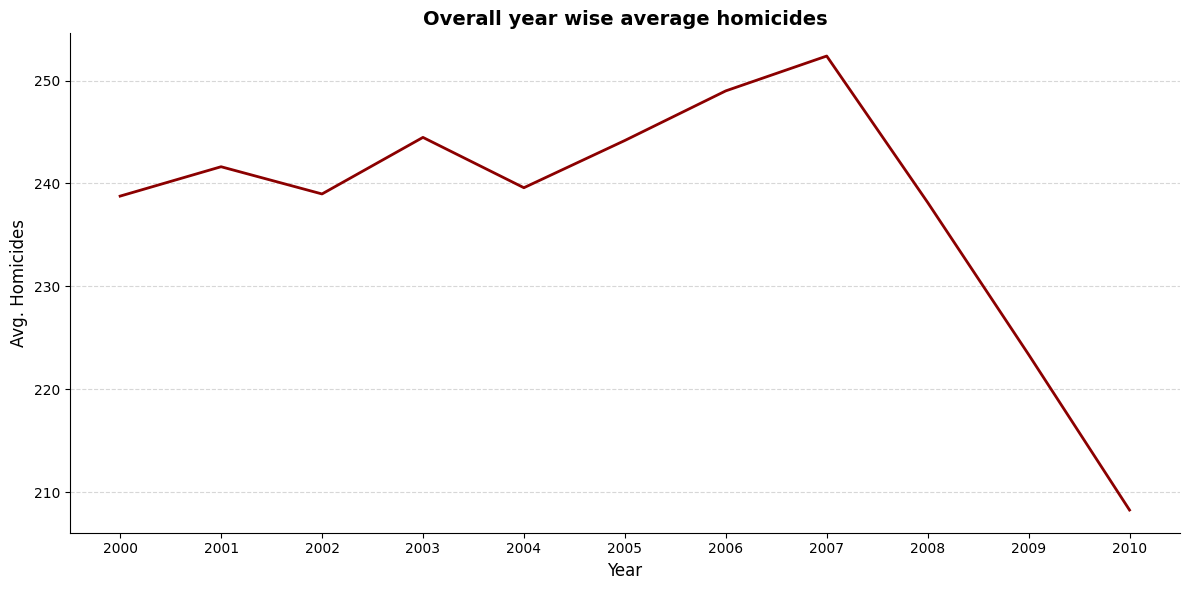

      year    homicide
0   2000.0  238.768137
1   2001.0  241.622999
2   2002.0  238.977605
3   2003.0  244.473430
4   2004.0  239.583584
5   2005.0  244.172501
6   2006.0  248.993795
7   2007.0  252.379803
8   2008.0  238.154427
9   2009.0  223.377329
10  2010.0  208.265586


In [289]:
df_by_year = df.groupby('year')['homicide'].sum().reset_index()

plt.figure(figsize=(12, 6))

axes = sns.lineplot(x='year', y='homicide', data=df_by_year, color='darkred', markers='0', linewidth=2)
axes.set_title('Overall year wise average homicides', fontsize=14, weight='bold')
axes.set_ylabel('Avg. Homicides', fontsize=12)
axes.set_xlabel('Year', fontsize=12)
axes.set_xticks(df_by_year['year'].unique().astype(int))

for p in axes.patches:
    h = p.get_height()
    axes.annotate(f'{h}',
                  (p.get_x() + p.get_width()/2., h),
                  ha='center', va='bottom', 
                  fontsize=10)
    
sns.despine()
axes.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(df_by_year)

Q12) Synthesize the results from your analyses (correlation heatmap, raw ATE, per‑state ATEs, CATE, DiD, plots). Based on this evidence, state whether you believe the Castle Doctrine had a causal effect, positive or negative, on homicide rates and justify your conclusion with specific findings. Then list the main limitations and identification threats in your approach.

Cite specific results (numbers or trends) that support or contradict a causal effect.
Identify likely confounders and how they could bias estimates.
Note methodological limitations (e.g., aggregated vs. within‑state effects, parallel trends assumption for DiD).

(There is no correct answer for this question so please be thorough in your response).

<span style="color:lightgreen"> Answer: </span>

A collective review of data through correlation analysis, ATEs, CATEs, DID, overall, or state level presents a convoluted picture; however, when several of these matrices and numbers are reviewed in comparison to each other, we can try to conclude the following:

 - Most of the crimes show positive correlation; however, this correlation is not a direct causation of each other, instead these crimes share multiple underlying causes, as per this data, poverty is one of such causes.

 - Overall ATE before vs after the doctrine, without adjusting or controlling for time varying confounders like poverty trends or change in police numbers, misleads and portrays that the number of brutal crimes like homicide and murders saw a rise after the implementation of the doctrine, as if the doctrine resulted in this increase. Here, ATE just captures the correlation over time and not the actual causal effect of the doctrine.

 - A state wise ATE in 2010 for the homicides for the majority of the states is negative and also close to the overall CATE (-0.208), which shows that in 2010, a modest decrease was observed in homicides, except for two states( 26 and 42), which individually show an increase in homicide despite the aggregated effect showing a decrease. This might be caused by some local dynamics of these states.

 - However, DID(0.131) shows that there is some increase in homicide after the treatment, but this does not reconcile with the negative CATE for 2010. This can be interpreted as if the doctrine in fact resulted in a slight increase in crime over the years. However, again, the selection of the control group and treatment group was not random, and they did not adjust or control for any confounders.

 - Finally, the year wise homicide averages show a clear downward trend from 2007 to 2010, which might indicate that the crime started to decrease from 2007 onwards as more and more states started to adopt the doctrine. However, we do not have enough information to make the claim and support it with numbers.

 
 In conclusion, there is not enough or strong causal evidence that suggests od decide that the doctrine reduced homicide rates. Most of the apparent effects in raw numbers are explained by confounders, existing poverty levels, demographic trends, or policing.


## **Part B - Analyzing the Impact of Digital Notes on GPA**

We tested whether taking notes digitally affects students' GPA. In an experiment with 1,000 students we recorded a binary indicator for digital note-taking, measured each student's change in GPA after one year, and logged weekly study hours (scaled). Use the file `digital_notes.csv` for the analysis. For this task, we will be using the `doWhy` library. Please refer to the documentation to solve this part: https://www.pywhy.org/dowhy/v0.13/getting_started/index.html.

Q13) Start by loading the data into a dataframe and displaying the first 5 rows of it.

In [212]:
dg_notes_df = pd.read_csv('digital_notes.csv')
print(dg_notes_df.iloc[:5,:])

   study_hours  digital_notes  effect_on_gpa
0    -0.228014          False      -0.116390
1     1.448314          False       0.793924
2     1.919683           True       1.555616
3     1.801566          False       0.991375
4     1.684526           True       1.425603


Q14) Plot the number of students who used digital notes versus those who did not. Use a clearly labeled plot, include a title and axis labels, and display the plot.

C:\Users\rana.taqveem\AppData\Local\Temp\ipykernel_13424\1999082165.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.countplot(x='digital_notes', data=dg_notes_df, palette=palette, edgecolor='black')


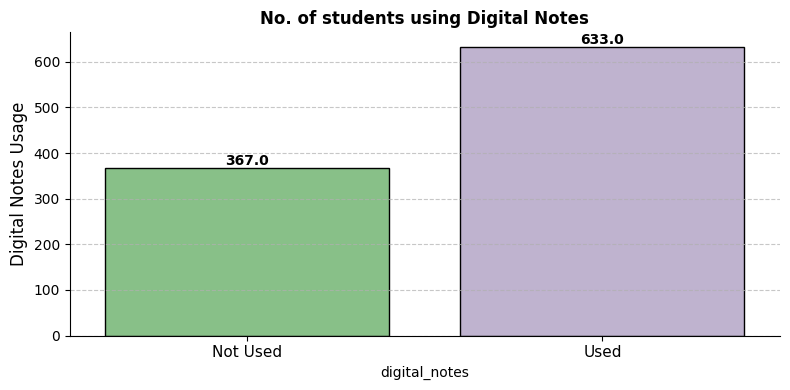

In [298]:
plt.figure(figsize=(8,4))
studens_used_dn = dg_notes_df[dg_notes_df['digital_notes'] == True]
# print(f"studens_used_dn: {len(studens_used_dn)}")
studens_notused_dn = dg_notes_df[dg_notes_df['digital_notes'] == False]
# print(f"studens_notused_dn: {len(studens_notused_dn)}")

palette = sns.color_palette("Accent", n_colors=2)
axes = sns.countplot(x='digital_notes', data=dg_notes_df, palette=palette, edgecolor='black')
axes.set_title('No. of students using Digital Notes', fontsize=12, weight='bold')
axes.set_ylabel('Digital Notes Usage', fontsize=12)
axes.set_xticks([False, True])
axes.set_xticklabels(['Not Used', 'Used'], fontsize=11)

for p in axes.patches:
    h = p.get_height()
    axes.annotate(f'{h}',
                  (p.get_x() + p.get_width()/2., h),
                  ha='center', va='bottom', 
                  fontsize=10, weight='bold')
    
sns.despine()
axes.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Q15.1) Althought counterintuitive at first, we make an informed hypothesis that weekly study hours could affect both digital note usage and GPA (think about what this means). Use this information and the given data to generate a `CausalModel` using the `doWhy` library. Visualise the constructed model.

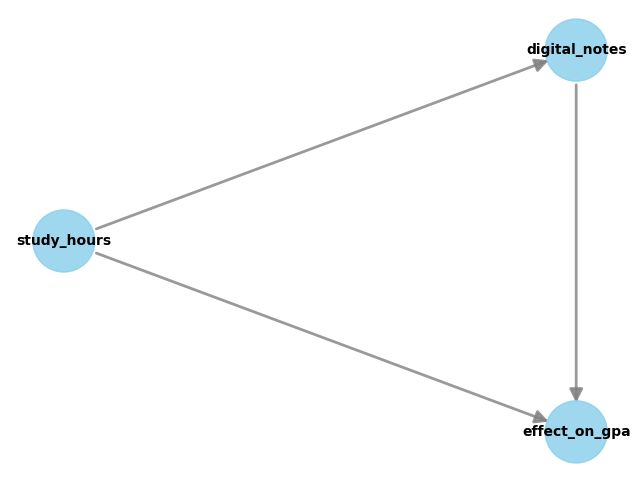

In [214]:
import networkx as nx
from dowhy import CausalModel, gcm

causal_graph = nx.DiGraph([('study_hours', 'digital_notes'), ('study_hours', 'effect_on_gpa'), ('digital_notes', 'effect_on_gpa')])

model = CausalModel(
    data=dg_notes_df,
    treatment='digital_notes',
    outcome='effect_on_gpa',
    graph=causal_graph
)

model.view_model()

# causal_model = gcm.StructuralCausalModel(causal_graph)
# auto_assignment_summary = gcm.auto.assign_causal_mechanisms(causal_model, df)
# print(auto_assignment_summary)



Q15.1) What is the confounding variable in our experiment?

<span style="color:lightgreen"> Answer: </span>

As per made out informeed hypothesis that 'Study Hours' could effect both the 'Digital Notes' and 'GPA' then 'Study Hours' is the confounding variable as it effecting both the treatment 'Digital Notes' and 'GPA' the outcome.

Q15.2) Use the constructed DAG to list all possible frontdoor and backdoor paths.

<span style="color:lightgreen"> Answer: </span>

1. Frontdoor Path: digital_note --> effect_on_gpa
2. Backdoor Path: digital_note <-- study_hours --> effect_on_gpa



Q16) Compute and report the ATE of digital note-taking on GPA using the dataframe.

In [215]:
groupedby_mean = dg_notes_df.groupby('digital_notes')['effect_on_gpa'].mean()
ATE = groupedby_mean.iloc[1] - groupedby_mean.iloc[0]
print(f"ATE: {ATE}")

ATE: 0.7618892735085776


Q17) Use the `doWhy` library to identify the effects of each variable and then print the identified estimand. (this is just one line of code -> read the documentation carefully)

In [202]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)



Q18) Using the identified estimate, use linear regression from `doWhy` to predict the causal estimate. 

In [216]:
causal_estimate = model.estimate_effect(identified_estimand=identified_estimand,
                      method_name="backdoor.linear_regression")

print(f"causal estimate: {causal_estimate.value}")
print(f"causal estimate: {causal_estimate}")


causal estimate: 0.4998145259209862
causal estimate: *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

## Realized estimand
b: effect_on_gpa~digital_notes+study_hours
Target units: ate

## Estimate
Mean value: 0.4998145259209862



Q19.1) We will now calculate the ATE using `LinearRegression` from the `sklearn` library. Do this without adjusting for the confounding variables first.

In [217]:
X = dg_notes_df[['digital_notes']]
y = dg_notes_df[['effect_on_gpa']]

linear_regression = LinearRegression()
linear_regression.fit(X, y)

LR_ATE = linear_regression.coef_[0]
print(f"Linear Regression ATE: {LR_ATE}")

Linear Regression ATE: [0.76188927]


Q19.2) Now, predict the ATE with adjustment for the confounding variable.

In [218]:

updated_model = CausalModel(
    data=dg_notes_df,
    treatment='digital_notes',
    outcome='effect_on_gpa',
    common_causes=['study_hours']
)

updated_identified_estimand = updated_model.identify_effect(proceed_when_unidentifiable=True)
print(updated_identified_estimand)

updated_causal_estimate = updated_model.estimate_effect(identified_estimand=updated_identified_estimand,
                      method_name="backdoor.linear_regression")

print(f"updated causal estimate: {updated_causal_estimate.value}")

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

updated causal estimate: 0.4998145259209862


Q20) Compare the unadjusted ATE and the ATE adjusted for study_hours. Report the numeric difference, explain why they differ, and state whether the evidence suggests digital note-taking improves GPA.

<span style="color:lightgreen"> Answer: </span>

Comparison of ATEs:

Unadjusted ATE: 0.76
Adjusted ATE (after controlling for study_hours): 0.498
Difference = 0.27

Explanation: The ATE without controlling for the 'study hours' resulted in higher ATE which misleads and suggests that using digital notes  increases GPA. However, after controlling for the confoudner study hours using dowhy the ATE reduced substantially to .49, much smaller than the unadjusted estimates. 

This shows that although there might be minor positive effect of digital notes on high GPA but most of the apparent benefit seen in the unadjusted regression was actually due to longer study hours and not becasue of the digital notes. As the students who study for loinger hours may also rely more on digital notes and means of study.